# Primary Model: CatBoost (Churn + Forward-Revenue) and Cox Survival

This is the project's primary/headline model: a CatBoost churn classifier, a CatBoost forward-revenue regressor, and a CatBoost-based Cox proportional-hazards survival model, all trained on `model_dataset_{train,val,test}.parquet` from `02_Feature_Engineering.ipynb` (post survivorship-bias fix) — except the Cox model, which uses its own full censoring-inclusive population (see that section below). The forward-revenue regressor also directly beat a Zero-Inflated LogNormal (ZILN) neural-net challenger trained on the same features (`03c_ZILN_ForwardRevenue.ipynb`, RMSE 131.5 vs. CatBoost's 127.9) rather than being assumed superior — see `results/fwd_rev_model_choice.json` for that comparison. The Cox framing is the statistically correct fit for a dataset this heavily censored (~62% of paying users have no confirmed outcome yet).

Categorical columns (`city_enc`, `gender_enc`, `registered_via_enc`, `payment_method_id_enc`) are passed to CatBoost as native categoricals (`cat_features=...`), not as raw integers — CatBoost fits its own ordered target-statistic encoding internally, which is a fairer treatment than feeding it the label-encoded integers as if they were ordinal.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import average_precision_score, mean_absolute_error, r2_score, roc_auc_score

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_train.parquet"))
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
FEATURE_COLS = CAT_COLS + NUM_COLS

# Hyperparameters tuned via Optuna - see 03b_Hyperparameter_Tuning.ipynb. That notebook
# searches at reduced iterations (300) to rank configs cheaply; this notebook applies the
# winning depth/learning_rate/regularization values at the full production iterations=1000.
with open(os.path.join(RESULTS_DIR, "optuna_best_params.json")) as f:
    OPTUNA_BEST_PARAMS = json.load(f)

print(f"features: {len(CAT_COLS)} categorical + {len(NUM_COLS)} numerical = {len(FEATURE_COLS)}")
print(f"train/val/test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")

features: 4 categorical + 23 numerical = 27
train/val/test: 1,127,119 / 241,526 / 241,526


## Churn classifier

Hyperparameters (`depth`, `learning_rate`, `l2_leaf_reg`, `bagging_temperature`, `random_strength`) tuned via Optuna — see `03b_Hyperparameter_Tuning.ipynb`.

In [2]:
churn_model = CatBoostClassifier(
    iterations=1000,
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=CAT_COLS,
    early_stopping_rounds=50,
    random_seed=42,
    thread_count=4,
    verbose=100,
    **OPTUNA_BEST_PARAMS["churn"],
)
churn_model.fit(
    train_df[FEATURE_COLS], train_df["is_churn"],
    eval_set=(val_df[FEATURE_COLS], val_df["is_churn"]),
)
churn_model.save_model(os.path.join(MODELS_DIR, "catboost_churn.cbm"))
print(f"best iteration: {churn_model.get_best_iteration()}")

0:	test: 0.8877043	best: 0.8877043 (0)	total: 447ms	remaining: 7m 26s


100:	test: 0.9536478	best: 0.9536478 (100)	total: 32.9s	remaining: 4m 52s


200:	test: 0.9570115	best: 0.9570115 (200)	total: 1m 6s	remaining: 4m 24s


300:	test: 0.9582126	best: 0.9582126 (300)	total: 1m 40s	remaining: 3m 53s


400:	test: 0.9592162	best: 0.9592162 (400)	total: 2m 14s	remaining: 3m 21s


...

700:	test: 0.9605003	best: 0.9605003 (700)	total: 4m 7s	remaining: 1m 45s


800:	test: 0.9608245	best: 0.9608245 (800)	total: 4m 46s	remaining: 1m 11s


900:	test: 0.9610402	best: 0.9610403 (899)	total: 5m 25s	remaining: 35.8s


999:	test: 0.9612594	best: 0.9612594 (999)	total: 6m 4s	remaining: 0us

bestTest = 0.9612593617
bestIteration = 999



best iteration: 999


## Auxiliary: payment-occurrence classifier (feature for the forward-revenue regressor)

`has_fwd_rev = (fwd_rev_59d > 0)` — whether a user pays *anything at all* in the 59-day forward window — is a genuinely different target from `is_churn` (35% of users disagree between the two: e.g. a user can miss the 30-day churn-grace renewal, count as `is_churn=1`, and still make one more payment before day 59). A diagnostic split of the forward-revenue regressor's errors by this flag found R²=0.087 among payers only, vs. 0.57 for a regressor trained only on payers in isolation — most of the single model's apparent skill was coming from separating payers from non-payers, not from predicting the paid amount. A naive two-stage hurdle model (`P(pay) x E[amount|pay]`, both trained independently) was tried and did *not* beat the single Tweedie model overall (compounding stage errors ate the gain) — but feeding `P(pay)` in **as an extra feature** to the same single Tweedie regressor did help in validation (RMSE 132.8→131.4, R² 0.329→0.342 at reduced iterations), which is what this section builds.

**Leakage guard**: a row can't be scored by a classifier that was trained on that same row's label, or the "feature" would just be smuggling the answer back in. Training splits use 2-fold cross-fitting — fit on fold A, predict fold B, and vice versa — so every `train_df` row's `p_pay_feature` comes from a model that never saw it. `val_df`/`test_df` use a single classifier fit on all of `train_df` (no leakage there either, since neither split was used to fit it). Reuses the tuned churn classifier's hyperparameters (same binary-CatBoost-classification shape) rather than running a separate Optuna search for an auxiliary model.

In [3]:
from sklearn.model_selection import KFold

train_df["has_fwd_rev"] = (train_df["fwd_rev_59d"] > 0).astype(int)
val_df["has_fwd_rev"] = (val_df["fwd_rev_59d"] > 0).astype(int)
test_df["has_fwd_rev"] = (test_df["fwd_rev_59d"] > 0).astype(int)


def build_pay_classifier():
    return CatBoostClassifier(
        iterations=1000,
        loss_function="Logloss",
        eval_metric="AUC",
        cat_features=CAT_COLS,
        early_stopping_rounds=50,
        random_seed=42,
        thread_count=4,
        verbose=False,
        **OPTUNA_BEST_PARAMS["churn"],
    )


train_df["p_pay_feature"] = np.nan
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fit_idx, pred_idx in kf.split(train_df):
    fold_clf = build_pay_classifier()
    fit_part = train_df.iloc[fit_idx]
    fold_clf.fit(fit_part[FEATURE_COLS], fit_part["has_fwd_rev"])
    train_df.iloc[pred_idx, train_df.columns.get_loc("p_pay_feature")] = (
        fold_clf.predict_proba(train_df.iloc[pred_idx][FEATURE_COLS])[:, 1]
    )

pay_clf = build_pay_classifier()
pay_clf.fit(train_df[FEATURE_COLS], train_df["has_fwd_rev"])
pay_clf.save_model(os.path.join(MODELS_DIR, "catboost_pay_clf.cbm"))
val_df["p_pay_feature"] = pay_clf.predict_proba(val_df[FEATURE_COLS])[:, 1]
test_df["p_pay_feature"] = pay_clf.predict_proba(test_df[FEATURE_COLS])[:, 1]

FWD_REV_FEATURE_COLS = FEATURE_COLS + ["p_pay_feature"]
print(f"full-data pay classifier: val AUC={roc_auc_score(val_df['has_fwd_rev'], val_df['p_pay_feature']):.4f}, "
      f"test AUC={roc_auc_score(test_df['has_fwd_rev'], test_df['p_pay_feature']):.4f}")

full-data pay classifier: val AUC=0.9881, test AUC=0.9880


## Forward-revenue regressor

Trained with a **Tweedie loss** directly on the raw `fwd_rev_59d` target (not the `log1p`-transformed version used elsewhere in this project) — `fwd_rev_59d` is zero-inflated (39.1% of users pay nothing in the 59-day window) and right-skewed for the rest, which is exactly the compound Poisson-Gamma shape Tweedie is built for, unlike a plain RMSE/Gaussian loss. Tested against a plain `RMSE`-on-`log1p` baseline (test RMSE 151.1 TWD, R² 0.163, on the original 13-feature set) and won clearly; on the current 27-feature set with Optuna-tuned hyperparameters, test RMSE is **127.9 TWD** and R² is **0.385** (MAE 50.3 TWD). Also beat a Zero-Inflated LogNormal (ZILN) neural-net challenger trained on the same features (`03c_ZILN_ForwardRevenue.ipynb`: RMSE 131.5, R² 0.349) — see `results/fwd_rev_model_choice.json` for that comparison. Hyperparameters (including `variance_power`) tuned via Optuna — see `03b_Hyperparameter_Tuning.ipynb`. Uses `FWD_REV_FEATURE_COLS` (the 27 shared features plus the cross-fit `p_pay_feature` from the section above) — the only model in this notebook with a feature set that differs from `FEATURE_COLS`.

In [4]:
fwd_rev_best_params = dict(OPTUNA_BEST_PARAMS["fwd_rev"])
fwd_rev_variance_power = fwd_rev_best_params.pop("variance_power")

fwd_rev_model = CatBoostRegressor(
    iterations=1000,
    loss_function=f"Tweedie:variance_power={fwd_rev_variance_power}",
    eval_metric="RMSE",
    cat_features=CAT_COLS,
    early_stopping_rounds=50,
    random_seed=42,
    thread_count=4,
    verbose=100,
    **fwd_rev_best_params,
)
fwd_rev_model.fit(
    train_df[FWD_REV_FEATURE_COLS], train_df["fwd_rev_59d"],
    eval_set=(val_df[FWD_REV_FEATURE_COLS], val_df["fwd_rev_59d"]),
)
fwd_rev_model.save_model(os.path.join(MODELS_DIR, "catboost_fwd_rev.cbm"))
print(f"best iteration: {fwd_rev_model.get_best_iteration()}")

0:	learn: 207.6795271	test: 208.6740200	best: 208.6740200 (0)	total: 415ms	remaining: 6m 54s


100:	learn: 204.7463652	test: 205.7516688	best: 205.7516688 (100)	total: 38.2s	remaining: 5m 40s


200:	learn: 204.7416749	test: 205.7497803	best: 205.7497706 (199)	total: 1m 17s	remaining: 5m 8s


300:	learn: 204.7386451	test: 205.7494712	best: 205.7494712 (300)	total: 1m 56s	remaining: 4m 29s


400:	learn: 204.7353753	test: 205.7494550	best: 205.7493357 (368)	total: 2m 34s	remaining: 3m 51s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 205.7493357
bestIteration = 368

Shrink model to first 369 iterations.


best iteration: 368


## Evaluation

In [5]:
def evaluate_churn(model, df):
    probs = model.predict_proba(df[FEATURE_COLS])[:, 1]
    return {
        "churn_auc_roc": roc_auc_score(df["is_churn"], probs),
        "churn_auc_pr": average_precision_score(df["is_churn"], probs),
    }


def evaluate_fwd_rev(model, df):
    # Tweedie model predicts fwd_rev_59d directly in raw TWD - no log1p/expm1 round-trip.
    # Uses FWD_REV_FEATURE_COLS (includes p_pay_feature), not the shared FEATURE_COLS.
    pred_raw = model.predict(df[FWD_REV_FEATURE_COLS])
    true_raw = df["fwd_rev_59d"].values
    return {
        "fwd_rev_rmse_raw_twd": float(np.sqrt(np.mean((pred_raw - true_raw) ** 2))),
        "fwd_rev_mae_raw_twd": float(mean_absolute_error(true_raw, pred_raw)),
        "fwd_rev_r2_raw": float(r2_score(true_raw, pred_raw)),
    }


catboost_results = {
    "churn": {"val": evaluate_churn(churn_model, val_df), "test": evaluate_churn(churn_model, test_df)},
    "fwd_rev": {"val": evaluate_fwd_rev(fwd_rev_model, val_df), "test": evaluate_fwd_rev(fwd_rev_model, test_df)},
}
with open(os.path.join(RESULTS_DIR, "catboost_results.json"), "w") as f:
    json.dump(catboost_results, f, indent=2)

print("Churn -- val/test:")
display(pd.DataFrame({"val": catboost_results["churn"]["val"], "test": catboost_results["churn"]["test"]}))
print("\nForward revenue -- val/test (RMSE/MAE in raw TWD):")
display(pd.DataFrame({"val": catboost_results["fwd_rev"]["val"], "test": catboost_results["fwd_rev"]["test"]}))

Churn -- val/test:


,val,test
churn_auc_roc,0.961259,0.960736
churn_auc_pr,0.983835,0.983643



Forward revenue -- val/test (RMSE/MAE in raw TWD):


,val,test
fwd_rev_rmse_raw_twd,129.914272,127.869172
fwd_rev_mae_raw_twd,50.585989,50.272614
fwd_rev_r2_raw,0.378339,0.384669


## Feature importance (CatBoost)

Quick sanity check on which features each task actually leans on.

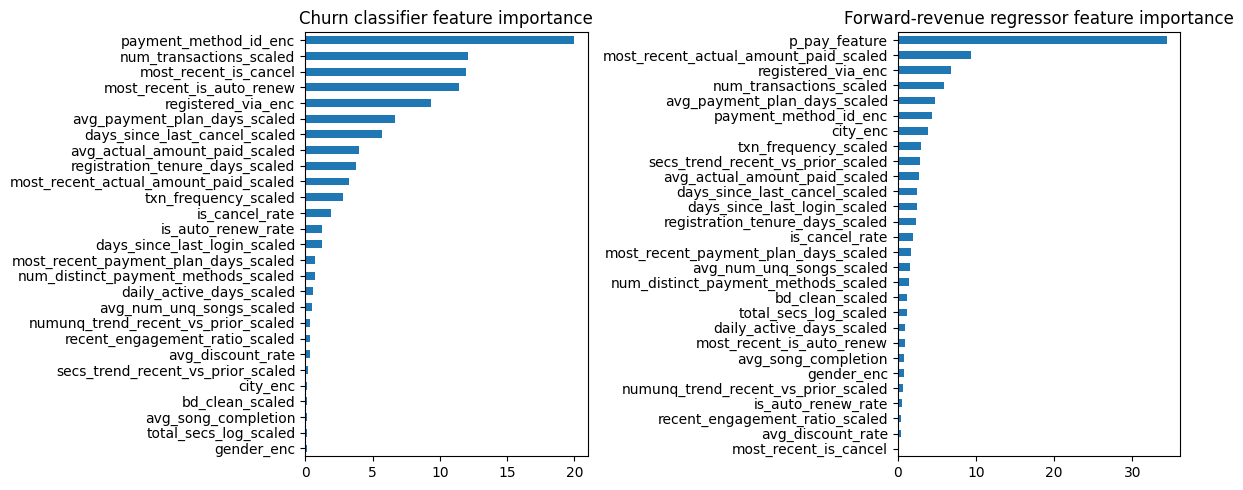

In [6]:
churn_importance = pd.Series(churn_model.get_feature_importance(), index=FEATURE_COLS).sort_values()
fwd_rev_importance = pd.Series(fwd_rev_model.get_feature_importance(), index=FWD_REV_FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
churn_importance.plot(kind="barh", ax=axes[0])
axes[0].set_title("Churn classifier feature importance")
fwd_rev_importance.plot(kind="barh", ax=axes[1])
axes[1].set_title("Forward-revenue regressor feature importance")
fig.tight_layout()

## Cox Proportional Hazards via CatBoost (survival analysis)

The second half of the primary model. CatBoost has a native `loss_function="Cox"` — gradient-boosted trees optimizing the Cox partial likelihood instead of a linear combination of covariates, giving a nonlinear/interaction-aware hazard model. Unlike the churn classifier above, this uses the **full censoring-inclusive paying population** (not `model_dataset`'s restricted population) — handling right-censored users properly is the entire point of a survival model, so restricting to only-confirmable cycles the way `02_Feature_Engineering.ipynb` does would defeat the purpose.

**Duration/event construction**: same per-user last-paid-cycle logic as `01_EDA.ipynb`'s Kaplan-Meier section — `duration_days` = first paid transaction to last-ever `membership_expire_date`, `event_churned = 1` if that expiry is confirmable (30+ days of runway before the 2017-02-28 data boundary), else censored. Also applies the same fix for the ~0.68% of transactions (mostly `is_cancel=1`) with a corrupted/reset `membership_expire_date` (excluded via an `expire_dt >= txn_dt` guard).

CatBoost's Cox loss expects the target as *signed* duration: positive for an observed event, negative for censored — same convention as XGBoost's `survival:cox`. Hyperparameters tuned via Optuna on this same population — see `03b_Hyperparameter_Tuning.ipynb`.

In [7]:
import duckdb

con = duckdb.connect()

con.execute(f"""
    create or replace temp table txn_cox as
    select *, strptime(cast(transaction_date as varchar), '%Y%m%d')::date as txn_dt,
           strptime(cast(membership_expire_date as varchar), '%Y%m%d')::date as expire_dt
    from '{os.path.join(PROCESSED_DIR, "transactions.parquet")}'
    where actual_amount_paid > 0
""")
# ref_date = each user's own last-ever paid cycle; min(txn_dt) is reliable, max(expire_dt)
# only considers rows with a plausible expiry (excludes the corrupted-reset ones)
con.execute("""
    create or replace temp table cox_ref as
    with valid_expiry as (
        select msno, expire_dt from txn_cox where expire_dt >= txn_dt
    )
    select t.msno, min(t.txn_dt) as start_dt, max(v.expire_dt) as ref_date,
           date_diff('day', min(t.txn_dt), max(v.expire_dt)) as duration_days,
           case when max(v.expire_dt) + interval 30 day <= date '2017-02-28' then 1 else 0 end as event_churned
    from txn_cox t
    join valid_expiry v using (msno)
    group by t.msno
""")

# Same 8 features added to 02_Feature_Engineering.ipynb (recency, most-recent-transaction
# snapshot, magnitude-based listening trend) - duplicated here since Cox rebuilds its own
# censoring-inclusive population rather than reading model_dataset's restricted one.
cox_query = f"""
    with txn_agg as (
        select t.msno, count(*) num_transactions,
               avg(t.payment_plan_days) avg_payment_plan_days,
               avg(t.actual_amount_paid) avg_actual_amount_paid,
               avg(t.is_auto_renew) is_auto_renew_rate
        from txn_cox t join cox_ref r using (msno)
        where t.txn_dt <= r.ref_date
        group by t.msno
    ),
    latest_txn as (
        select msno, payment_method_id, payment_plan_days as most_recent_payment_plan_days,
               actual_amount_paid as most_recent_actual_amount_paid,
               is_auto_renew as most_recent_is_auto_renew, is_cancel as most_recent_is_cancel
        from (
            select t.msno, t.payment_method_id, t.payment_plan_days, t.actual_amount_paid,
                   t.is_auto_renew, t.is_cancel,
                   row_number() over (partition by t.msno order by t.txn_dt desc) rn
            from txn_cox t join cox_ref r using (msno)
            where t.txn_dt <= r.ref_date
        ) where rn = 1
    ),
    last_login as (
        select l.msno, max(l.log_dt) as last_login_dt
        from (select *, strptime(cast(date as varchar), '%Y%m%d')::date as log_dt
              from '{os.path.join(PROCESSED_DIR, "user_logs.parquet")}') l
        join cox_ref r using (msno)
        where l.log_dt <= r.ref_date
        group by l.msno
    ),
    last_cancel as (
        select t.msno, max(t.txn_dt) as last_cancel_dt
        from txn_cox t join cox_ref r using (msno)
        where t.txn_dt <= r.ref_date and t.is_cancel = 1
        group by t.msno
    ),
    logs_agg as (
        select l.msno,
               count(distinct l.log_dt) daily_active_days,
               sum(greatest(least(l.total_secs, 86400), 0)) total_secs_sum,
               sum(l.num_25) sum25, sum(l.num_50) sum50, sum(l.num_75) sum75,
               sum(l.num_985) sum985, sum(l.num_100) sum100,
               sum(greatest(least(l.total_secs, 86400), 0))
                   filter (where l.log_dt >= r.ref_date - interval 6 day) as recent7_secs,
               sum(greatest(least(l.total_secs, 86400), 0))
                   filter (where l.log_dt < r.ref_date - interval 6 day) as prior23_secs,
               sum(l.num_unq) filter (where l.log_dt >= r.ref_date - interval 6 day) as recent7_numunq,
               sum(l.num_unq) filter (where l.log_dt < r.ref_date - interval 6 day) as prior23_numunq
        from (select *, strptime(cast(date as varchar), '%Y%m%d')::date as log_dt
              from '{os.path.join(PROCESSED_DIR, "user_logs.parquet")}') l
        join cox_ref r using (msno)
        where l.log_dt >= r.ref_date - interval 29 day and l.log_dt <= r.ref_date
        group by l.msno
    )
    select r.msno, r.ref_date, r.duration_days, r.event_churned,
           m.city, m.bd, m.gender, m.registered_via, m.registration_init_time,
           coalesce(txn_agg.num_transactions, 0) num_transactions,
           txn_agg.avg_payment_plan_days, txn_agg.avg_actual_amount_paid,
           coalesce(txn_agg.is_auto_renew_rate, 0) is_auto_renew_rate,
           latest_txn.payment_method_id,
           latest_txn.most_recent_payment_plan_days, latest_txn.most_recent_actual_amount_paid,
           coalesce(latest_txn.most_recent_is_auto_renew, 0) most_recent_is_auto_renew,
           coalesce(latest_txn.most_recent_is_cancel, 0) most_recent_is_cancel,
           date_diff('day', ll.last_login_dt, r.ref_date) as days_since_last_login,
           date_diff('day', lc.last_cancel_dt, r.ref_date) as days_since_last_cancel,
           coalesce(logs_agg.daily_active_days, 0) daily_active_days,
           coalesce(logs_agg.total_secs_sum, 0) total_secs_sum,
           coalesce(logs_agg.sum25,0) sum25, coalesce(logs_agg.sum50,0) sum50,
           coalesce(logs_agg.sum75,0) sum75, coalesce(logs_agg.sum985,0) sum985,
           coalesce(logs_agg.sum100,0) sum100,
           coalesce(logs_agg.recent7_secs, 0) recent7_secs, coalesce(logs_agg.prior23_secs, 0) prior23_secs,
           coalesce(logs_agg.recent7_numunq, 0) recent7_numunq, coalesce(logs_agg.prior23_numunq, 0) prior23_numunq
    from cox_ref r
    left join '{os.path.join(PROCESSED_DIR, "members.parquet")}' m using (msno)
    left join txn_agg using (msno)
    left join latest_txn using (msno)
    left join last_login ll using (msno)
    left join last_cancel lc using (msno)
    left join logs_agg using (msno)
"""
cox_df = con.execute(cox_query).df()
print(f"survival feature table: {cox_df.shape}")
print(f"event rate: {cox_df['event_churned'].mean():.3f}  (censored: {1 - cox_df['event_churned'].mean():.3f})")
assert (cox_df["duration_days"] >= 0).all()

survival feature table: (1734274, 31)
event rate: 0.375  (censored: 0.625)


In [8]:
from sklearn.model_selection import train_test_split

# Same derived features as 02_Feature_Engineering.ipynb, computed relative to each
# user's own ref_date instead of a shared cutoff.
reg_date = pd.to_datetime(
    cox_df["registration_init_time"].astype("Int64").astype(str), format="%Y%m%d", errors="coerce"
)
cox_df["registration_tenure_days"] = (pd.to_datetime(cox_df["ref_date"]) - reg_date).dt.days
cox_df["gender"] = cox_df["gender"].fillna("unknown")
cox_df["city"] = cox_df["city"].fillna(-1).astype(int)
cox_df["registered_via"] = cox_df["registered_via"].fillna(-1).astype(int)
cox_df["bd_clean"] = cox_df["bd"].where(cox_df["bd"].between(1, 100))

song_totals = cox_df[["sum25", "sum50", "sum75", "sum985", "sum100"]].sum(axis=1)
cox_df["avg_song_completion"] = (
    0.25 * cox_df["sum25"] + 0.50 * cox_df["sum50"] + 0.75 * cox_df["sum75"]
    + 0.985 * cox_df["sum985"] + 1.0 * cox_df["sum100"]
) / (song_totals + 1)
cox_df["total_secs_log"] = np.log1p(cox_df["total_secs_sum"])
cox_df["secs_trend_recent_vs_prior"] = (cox_df["recent7_secs"] / 7.0) / ((cox_df["prior23_secs"] / 23.0) + 1)
cox_df["numunq_trend_recent_vs_prior"] = (cox_df["recent7_numunq"] / 7.0) / ((cox_df["prior23_numunq"] / 23.0) + 1)

COX_CAT_COLS = ["city", "gender", "registered_via", "payment_method_id"]
COX_NUM_COLS = [
    "bd_clean", "registration_tenure_days", "avg_payment_plan_days", "avg_actual_amount_paid",
    "num_transactions", "total_secs_log", "daily_active_days", "is_auto_renew_rate", "avg_song_completion",
    "days_since_last_login", "days_since_last_cancel",
    "secs_trend_recent_vs_prior", "numunq_trend_recent_vs_prior",
    "most_recent_payment_plan_days", "most_recent_actual_amount_paid",
    "most_recent_is_auto_renew", "most_recent_is_cancel",
]

cox_train, cox_temp = train_test_split(cox_df, test_size=0.30, stratify=cox_df["event_churned"], random_state=42)
cox_val, cox_test = train_test_split(cox_temp, test_size=0.50, stratify=cox_temp["event_churned"], random_state=42)
cox_splits = {"train": cox_train, "val": cox_val, "test": cox_test}

# median imputation fit on train only (own splits -- this is a different population
# than model_dataset, so it gets its own imputation statistics, not 02's saved ones)
for col in [
    "bd_clean", "registration_tenure_days", "avg_payment_plan_days", "avg_actual_amount_paid",
    "most_recent_payment_plan_days", "most_recent_actual_amount_paid",
]:
    median = cox_train[col].median()
    for split in cox_splits.values():
        split[col] = split[col].fillna(median)

# Recency sentinels, same treatment as 02_Feature_Engineering.ipynb: "never logged in"/
# "never canceled" are legitimate states, not missing data - a sentinel larger than any
# real observed gap keeps them correctly ordered for a tree-based split.
login_sentinel_cox = cox_train["days_since_last_login"].max() + 30
cancel_sentinel_cox = cox_train["days_since_last_cancel"].max() + 30
for split in cox_splits.values():
    split["days_since_last_login"] = split["days_since_last_login"].fillna(login_sentinel_cox)
    split["days_since_last_cancel"] = split["days_since_last_cancel"].fillna(cancel_sentinel_cox)

for name, split in cox_splits.items():
    print(f"{name:6s} n={len(split):>7,}  event_rate={split['event_churned'].mean():.4f}")

train  n=1,213,991  event_rate=0.3747
val    n=260,141  event_rate=0.3747
test   n=260,142  event_rate=0.3747


In [9]:
from lifelines.utils import concordance_index

# signed duration: positive = observed event, negative = censored (CatBoost/XGBoost Cox convention).
# +0.5 offset avoids the ambiguous case where duration_days == 0 (0.5% of users) --
# a bare 0 has no sign, so +0/-0 would collapse the event/censored distinction for them.
for split in cox_splits.values():
    signed_duration = split["duration_days"] + 0.5
    split["cox_target"] = np.where(split["event_churned"] == 1, signed_duration, -signed_duration)

cox_model = CatBoostRegressor(
    iterations=1000,
    loss_function="Cox",
    cat_features=COX_CAT_COLS,
    early_stopping_rounds=50,
    random_seed=42,
    thread_count=4,
    verbose=100,
    **OPTUNA_BEST_PARAMS["cox"],
)
cox_model.fit(
    cox_train[COX_CAT_COLS + COX_NUM_COLS], cox_train["cox_target"],
    eval_set=(cox_val[COX_CAT_COLS + COX_NUM_COLS], cox_val["cox_target"]),
)
cox_model.save_model(os.path.join(MODELS_DIR, "catboost_cox.cbm"))
print(f"best iteration: {cox_model.get_best_iteration()}")

cox_results = {}
for name in ["val", "test"]:
    split = cox_splits[name]
    risk_score = cox_model.predict(split[COX_CAT_COLS + COX_NUM_COLS])
    # concordance_index expects higher score = longer survival, so negate the risk score
    c_index = concordance_index(split["duration_days"], -risk_score, split["event_churned"])
    cox_results[name] = {"concordance_index": c_index}
    print(f"{name}: concordance index = {c_index:.4f}")

with open(os.path.join(RESULTS_DIR, "cox_results.json"), "w") as f:
    json.dump(cox_results, f, indent=2)

0:	learn: -6141340.5678677	test: -1165962.3258092	best: -1165962.3258092 (0)	total: 1.28s	remaining: 21m 23s


100:	learn: -5667429.3789565	test: -1064518.1089373	best: -1064518.1089373 (100)	total: 59.4s	remaining: 8m 49s


200:	learn: -5474579.0790397	test: -1023274.1439223	best: -1023274.1439223 (200)	total: 1m 54s	remaining: 7m 34s


300:	learn: -5372351.7340139	test: -1001471.1672221	best: -1001471.1672221 (300)	total: 2m 48s	remaining: 6m 30s


400:	learn: -5311936.5279091	test: -988683.0215869	best: -988683.0215869 (400)	total: 3m 41s	remaining: 5m 30s


...

800:	learn: -5204243.8838360	test: -966427.6793676	best: -966427.6793676 (800)	total: 7m 15s	remaining: 1m 48s


900:	learn: -5192081.7087587	test: -964208.4843385	best: -964208.4843385 (900)	total: 8m 7s	remaining: 53.6s


999:	learn: -5182075.4868394	test: -962384.9776772	best: -962384.9776772 (999)	total: 9m 1s	remaining: 0us

bestTest = -962384.9777
bestIteration = 999

best iteration: 999


val: concordance index = 0.9646


test: concordance index = 0.9649


Concordance index (test): 0.9649
(0.5 = random ranking, 1.0 = perfect ranking -- same intuition as AUC-ROC, but over survival time)


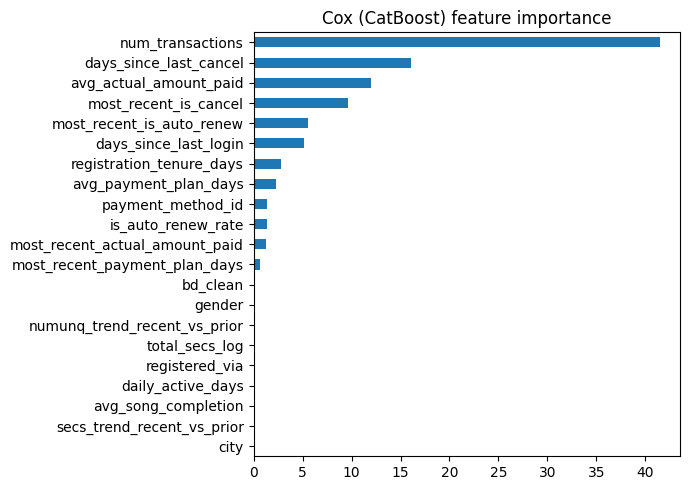

In [10]:
cox_importance = pd.Series(
    cox_model.get_feature_importance(), index=COX_CAT_COLS + COX_NUM_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
cox_importance.plot(kind="barh", ax=ax)
ax.set_title("Cox (CatBoost) feature importance")
fig.tight_layout()

print(f"Concordance index (test): {cox_results['test']['concordance_index']:.4f}")
print("(0.5 = random ranking, 1.0 = perfect ranking -- same intuition as AUC-ROC, but over survival time)")